In [1]:
import numpy as np
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
pwd

'/Users/nonon/mamba-root/notebooks/ESN-LSTM/source/Stage-INRIA-2025'

In [2]:
# load data
data = np.load('50k_dataset.npy')
split_index = int(len(data)*0.75)
X = data[:, :8]
Y = data[:, 11].reshape(-1, 1)

In [4]:
reservoir = Reservoir(
    units=1000,
    sr=0.540,
    lr=0.0425,
    input_scaling=0.587,
    rc_connectivity=0.1,
    input_connectivity=0.1,
    noise_rc=0.00179,
    input_bias=True,
    seed=12
)
#rpy.set_seed(42)

In [5]:
readout = Ridge(ridge=0.00000548, output_dim=1, input_bias=True)
ESN = reservoir >> readout

# train
ESN.fit(X[:split_index], Y[:split_index], warmup=500)
#print(reservoir.state())
# run
Y_pred = ESN.run(X[split_index:],return_states=[reservoir.name,readout.name])

Running Model-0:   0%|                                    | 0/1 [00:00<?, ?it/s]
Running Model-0: 583it [00:00, 5827.21it/s]                                     
Running Model-0: 1174it [00:00, 5870.79it/s]
Running Model-0: 1762it [00:00, 5868.50it/s]
Running Model-0: 2355it [00:00, 5888.91it/s]
Running Model-0: 2949it [00:00, 5905.52it/s]
Running Model-0: 3540it [00:00, 5903.68it/s]
Running Model-0: 4131it [00:00, 5895.98it/s]
Running Model-0: 4721it [00:00, 5887.71it/s]
Running Model-0: 5315it [00:00, 5901.44it/s]
Running Model-0: 5908it [00:01, 5908.29it/s]
Running Model-0: 6499it [00:01, 5902.34it/s]
Running Model-0: 7092it [00:01, 5908.08it/s]
Running Model-0: 7683it [00:01, 5895.45it/s]
Running Model-0: 8273it [00:01, 5888.93it/s]
Running Model-0: 8862it [00:01, 5871.97it/s]
Running Model-0: 9450it [00:01, 5857.92it/s]
Running Model-0: 10036it [00:01, 5823.22it/s]
Running Model-0: 10624it [00:01, 5837.75it/s]
Running Model-0: 11213it [00:01, 5851.20it/s]
Running Model-0: 11799it 

Fitting node Ridge-0...
[[-0.40087026  0.89649039  0.81744897  0.27216448 -0.18583554  0.18453834
  -0.07938898  0.72447612  0.83326066  0.16607433  0.10923385  0.3445314
   0.48287497  0.4426988   0.15432138  0.24785939 -0.32770567 -0.43958999
  -0.55729363  0.65093984  0.84465964 -0.68970882 -0.44391829 -0.61244531
   0.21097646  0.22702453 -0.02567804  0.30751614 -0.27072315  0.64955909
  -0.48343794  0.01624003 -0.88812442  0.41055033 -0.36756399 -0.8617313
  -0.0439355   0.20688212 -0.29067629  0.11352071 -0.92067597 -0.84974382
   0.02069653  0.64776456  0.18830761 -0.34767307  0.24035121  0.43837109
   0.46372746 -0.45234038  0.44431739  0.63642321  0.33950464 -0.55890513
   0.36639955 -0.06508102  0.48434477  0.59561113 -0.92437204  0.30944079
   0.84008748  0.95208243  0.36361848 -0.60792045  0.85223569  0.35066465
   0.82834983  0.24395786 -0.43980658 -0.60374712  0.80127612  0.22992584
   0.07425727  0.10819346 -0.27901534  0.42681627 -0.66614269 -0.47094542
   0.44326931  0

Running Model-0: 12500it [00:02, 6031.88it/s]                                   


In [6]:
from reservoirpy.observables import nrmse, rsquare, mse
print(f"NRMSE: {nrmse(Y[split_index:], Y_pred[readout.name]):.4f}")
print(f"R2: {rsquare(Y[split_index:], Y_pred[readout.name]):.4f}")
print(reservoir.is_initialized, readout.is_initialized, readout.fitted)
print(mse(Y[split_index:],Y_pred[readout.name]))

NRMSE: 0.1095
R2: 0.2990
True True True
11.694464702177942


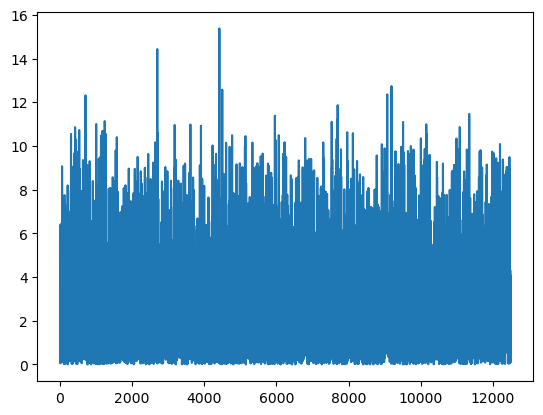

In [7]:
import matplotlib.pyplot as plt
plt.plot(abs(Y[split_index:]-Y_pred[readout.name]))

In [10]:
def line_intersect(p1, p2, P3, P4):
    # calcule les coordonnées des points d'intersections entre deux segments. Ici entre le rayon du senseur et du mur

    # on récupère les coodonnées de tous les segments que formé par les senseurs
    p1 = np.atleast_2d(p1) 
    p2 = np.atleast_2d(p2)
    # on récupère les coordonnées des segments des murs du labyrinthe
    P3 = np.atleast_2d(P3)
    P4 = np.atleast_2d(P4)
    
    x1, y1 = p1[:,0], p1[:,1]
    x2, y2 = p2[:,0], p2[:,1]
    X3, Y3 = P3[:,0], P3[:,1]
    X4, Y4 = P4[:,0], P4[:,1]

    #colinéarité entre le vecteur senseur et le mur 
    D = (Y4-Y3)*(x2-x1) - (X4-X3)*(y2-y1)

    # Colinearity test
    C = (D != 0)
    UA = ((X4-X3)*(y1-Y3) - (Y4-Y3)*(x1-X3))
    UA = np.divide(UA, D, where=C)
    UB = ((x2-x1)*(y1-Y3) - (y2-y1)*(x1-X3))
    UB = np.divide(UB, D, where=C)

    # Test if intersections are inside each segment
    C = C * (UA > 0) * (UA < 1) * (UB > 0) * (UB < 1)
    
    X = np.where(C, x1 + UA*(x2-x1), np.inf)
    Y = np.where(C, y1 + UA*(y2-y1), np.inf)
    return np.stack([X,Y],axis=1)

In [9]:
walls = np.array( [

            # Surrounding walls
            [ (  0,   0), (  0, 500)],
            [ (  0, 500), (300, 500)],
            [ (300, 500), (300,   0)],
            [ (300,   0), (  0,   0)],
            
            # Bottom hole
            [ (100, 100), (200, 100)],
            [ (200, 100), (200, 200)],
            [ (200, 200), (100, 200)],
            [ (100, 200), (100, 100)],

            # Top hole
            [ (100, 300), (200, 300)],
            [ (200, 300), (200, 400)],
            [ (200, 400), (100, 400)],
            [ (100, 400), (100, 300)]
        ] )
print(walls.shape)


(12, 2, 2)


In [9]:
theta=ESN.run(data[-1,:8])
print(theta)

Running Model-0: 100%|███████████████████████████| 1/1 [00:00<00:00, 440.35it/s]

[[1.74669181]]


In [11]:
A = np.linspace(-np.pi/2, +np.pi/2, 8, endpoint=True)
sensors = {
    "angle" : A,
    "range" : 75*np.ones((8,1)),
    "value" : np.ones((8,1)) }

sensors["range"][3:5] *= 1.25
print(sensors["range"])
orientation=np.array(data[split_index,11])
position=np.array([data[split_index,9],data[split_index,10]]).reshape((1,2))
position+= 2 * np.array([np.cos(float(orientation)),np.sin(float(orientation))]).reshape((1,2))
print(f'position:{position}')
print(f'orientation:{orientation}')
size=10
pred=len(data)-split_index
naomi=np.zeros((pred,13))
for n in range(pred):
    A = sensors["angle"] + orientation # angles de tous les senseurs
    T = np.stack([np.cos(A), np.sin(A)], axis=1) # gradient ? de tous les angles des senseurs
    P1 = position + size*T # positions dans le plan de tous les senseurs du robot
    P2 = P1 + sensors["range"]*T # coordonées de la fin du segment formé a partir du senseur et jusq'uà sa distance de vision
    P3, P4 = walls[:,0], walls[:,1] # coordonnées de tous les murs du labyrinthe 
    for i, (p1, p2) in enumerate(zip(P1,P2)): # pour tous les segments robot-range 
        C = line_intersect(p1, p2, P3, P4) # calcul du point d'intersection entre la vision et le mur du labyrinthe
        index = np.argmin( ((C - p1)**2).sum(axis=1)) # somme des distances au carré du robot aux intersections, on obtient le nom du senseur de plus petit distance au mur 
        p = C[index] # on récupère la plus petite distance au mur
        if p[0] < np.inf: # si la distance est finie alors:
            sensors["value"][i] = np.sqrt(((p1-p)**2).sum())+np.random.normal(loc=0,scale=1)
            sensors["value"][i] /= sensors["range"][i]
        else:
            sensors["value"][i] = 1
    naomi[n,:8]=sensors["value"].reshape((8,))
    dv=float(ESN(naomi[n,:8]))
    if abs(theta) > 0.5:
        orientation += 0.015*dv
        #print(orientation)
    else: dv=0
    naomi[n,9]=dv
    position += 2 * np.array([np.cos(float(orientation)),np.sin(float(orientation))]).reshape((1,2))
    naomi[n,10],naomi[n,11]=position[0,0],position[0,1]
    naomi[n,12]=orientation


"""
for i in range(pred):
    A = sensors["angle"] + orientation # angles de tous les senseurs
    #print(A)
    T = np.stack([np.cos(A), np.sin(A)], axis=1).reshape((2,8))
    #print(T) # gradient ? de tous les angles des senseurs
    P1 = size*T +position*np.ones((2,8))# (8, 2)
    print(P1)
    P2 = P1 + T * sensors["range"].reshape((1,8)) 
    print(P2)
    #print(np.shape(list(zip(P1,P2))))          # (8, 2) # coordonées de la fin du segment formé a partir du senseur et jusq'uà sa distance de vision
    P3, P4 = walls[:,0], walls[:,1] # coordonnées de tous les murs du labyrinthe 
    for n, (p1, p2) in enumerate(np.stack([P1,P2],axis=1)): # pour tous les segments robot-range 
        C = line_intersect(p1, p2, P3, P4)
        print(p1)
        print(C) # calcul du point d'intersection entre la vision et le mur du labyrinthe
        index = np.argmin( ((C - p1)**2).sum(axis=1)) # somme des distances au carré du robot aux intersections, on obtient le nom du senseur de plus petit distance au mur 
        p = C[index] # on récupère la plus petite distance au mur
        if p[0] < np.inf: # si la distance est finie alors:
            naomi[i,n] = np.sqrt(((p1-p)**2).sum())
            naomi[i,n] /= sensors["range"][n]
            #self.sensors["value"][i]+=np.random.normal(loc=0,scale=0.5)
        else:
            naomi[i,n]= 1
    dv=esn_model.run(naomi[i,0:7])
    if abs(dv) > 0.5:
        orientation += 0.01*dv
        #print(orientation)
    else: dv=0
    naomi[i,8]=dv
    position += 2 * np.array([np.cos(float(orientation)),np.sin(float(orientation))]).reshape((2,1))
    naomi[i,9],naomi[i,10]=position
    naomi[i,11]=orientation"""

[[75.  ]
 [75.  ]
 [75.  ]
 [93.75]
 [93.75]
 [75.  ]
 [75.  ]
 [75.  ]]
position:[[264.27453703  -7.11299774]]
orientation:5.774451312152949


/var/folders/vj/hg5506hd0sb__t4fn08ds0br0000gn/T/ipykernel_7355/3049577763.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dv=float(ESN(naomi[n,:8]))


NameError: name 'theta' is not defined

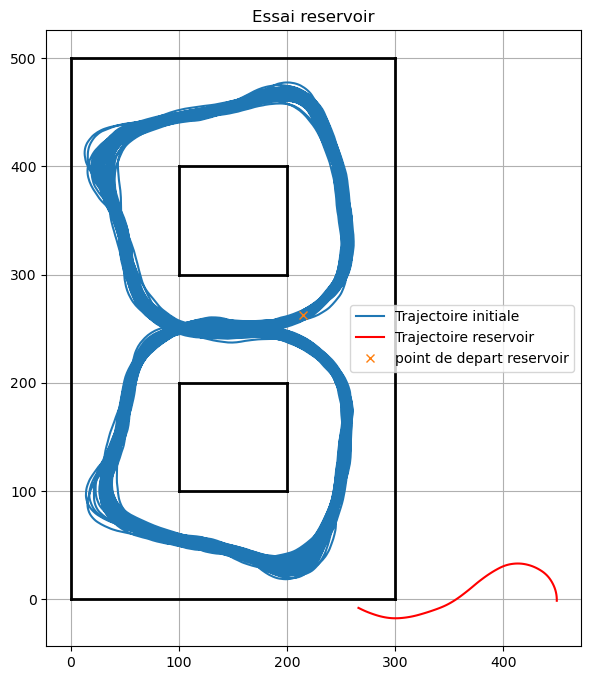

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))

# Tracé des murs
for wall in walls:
    (x1, y1), (x2, y2) = wall
    ax.plot([x1, x2], [y1, y2], 'k-', linewidth=2)

# Tracé de la trajectoire du robot
ax.plot(data[:split_index,8],data[:split_index,9],label='Trajectoire initiale')
ax.plot(naomi[:110,10], naomi[:110,11], 'r-', label='Trajectoire reservoir')
ax.plot(data[split_index,8],data[split_index,9], 'x', label='point de depart reservoir')
# Options d'affich
##ax.set_xlim(0, 300)
#ax.set_ylim(0, 500)
ax.set_aspect('equal')
ax.set_title('Essai reservoir')
ax.legend()
plt.grid(True)
plt.show()

## ******************************************

In [10]:
#reservoir_states = reservoir.run(X[split_index:])
#print(reservoir_states.shape)

Running Reservoir-1: 100%|██████████████| 12500/12500 [00:06<00:00, 2006.55it/s]

(12500, 1400)


In [5]:
all_states = reservoir.run(X, reset=False) 
reservoir_states = all_states[split_index:]

Running Reservoir-0: 100%|██████████████| 50000/50000 [00:25<00:00, 1994.75it/s]


In [9]:
xy_coords = data[split_index:, 8:10]

In [10]:
def get_yellow_zone_labels(xy):
    yellow_mask = (xy[:, 0] > 100) & (xy[:, 0] < 200) & \
                  (xy[:, 1] > 200) & (xy[:, 1] < 300)
    
    labels = np.zeros(len(xy), dtype=int)
    current_label = 0
    prev_zone = None

    for i in range(len(xy)):
        if xy[i][1] > 300:
            zonet1 = 1
        elif xy[i][1] < 200:
            zonet1 = 4
        elif xy[i][0] < 150:
            zonet1 = 2
        else:
            zonet1 = 3

        # only update label on zone 2 or 3 transitions
        if zonet1 != prev_zone:
            if zonet1 == 2:
                current_label = 1  # just did left, next is right
            elif zonet1 == 3:
                current_label = 0  # just did right, next is left        
        prev_zone = zonet1
        
        if yellow_mask[i]:
            labels[i] = current_label

    return labels, yellow_mask

In [11]:
data_labels, yellow_mask = get_yellow_zone_labels(xy_coords)
decision_states = reservoir_states[yellow_mask]    # reservoir states in yellow zone
decision_labels = data_labels[yellow_mask]

In [12]:
split = int(0.7 * len(decision_states))
reservoir_states_train, reservoir_states_test = decision_states[:split], decision_states[split:]
labels_train, labels_test = decision_labels[:split], decision_labels[split:]

In [13]:
for k in range(2, 9):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(reservoir_states_train, labels_train)
    acc = accuracy_score(labels_test, knn.predict(reservoir_states_test))
    print(f"K={k} accuracy: {acc:.4f}")

K=2 accuracy: 0.7771
K=3 accuracy: 0.8101
K=4 accuracy: 0.7984
K=5 accuracy: 0.8178
K=6 accuracy: 0.8140
K=7 accuracy: 0.8236
K=8 accuracy: 0.8140


In [6]:
# run full sequence through trained model
split_index = 25_000
Y_pred = ESN.run(X[split_index:])  # shape: (2500, 1)
Y_true = Y[split_index:]

from reservoirpy.observables import nrmse, rsquare

nrmse_score = nrmse(Y_true, Y_pred)
r2_score = rsquare(Y_true, Y_pred)

print(f"NRMSE: {nrmse_score:.4f}")  # paper reports 0.0171
print(f"R2: {r2_score:.4f}")        # paper reports 0.9962

AttributeError: 'numpy.ndarray' object has no attribute 'input_nodes'

In [2]:
pwd

'/Users/nonon/mamba-root/notebooks/ESN-LSTM/source/Stage-INRIA-2025'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import reservoirpy as rpy
from reservoirpy.datasets import mackey_glass
from reservoirpy.nodes import Reservoir, Ridge, FORCE, ESN,Input
from reservoirpy.observables import mse, nrmse, rsquare

from numpy import *
import scipy as scp

rpy.verbosity(0)  # no need to be too verbose here
#rpy.set_seed(1234) # make everything reproducible!

# a cause de la taille de l'echantillon d'entrainement, le robot arrive au bout de 7500 itérations 
# dans la zone 2, le pattern ne saurait donc etre changé et la taille du setb non plus avant de savoir
# précisément dans quelle zone le robot est a la fin de l'entrainement 
# 


#Data_set=np.load('50k_dataset.npy')
Data_set=np.load('dataset_bretenberg.npy')
X=Data_set[:,:8]
Y=Data_set[:,11].reshape(-1,1)

"""X=np.load('input.npy')
Y=np.load('output.npy')
theta=np.load('positions.npy')
"""
#training_len=int(50000*0.5)
training_len=7000
data_size=len(Y)

"""
robot_model = {
                "N": 1400, 
                "sr": 1.4,            #0.5818465976198328, 
                "lr": 0.0181,            #0.09209147803011875, 
                "input_scaling": 1.0,  # 8.978506821451717, 
                "seed": 784,           #26070 other seed
                "ridge": 4.1e-8,         #0.13953840268837053, 
                "input_connectivity": 0.2,
                "connectivity": 0.19,
                "noise_rc": 1e-2          #5.437647652528754e-05 
            }
"""

robot_model = {
                "N": 1000, 
                "sr": 0.540,
                "lr": 0.0425,
                "input_scaling": 0.587,
                "seed": 12,
                "ridge": 0.00000548,
                "input_connectivity": 0.1,
                "connectivity": 0.1,
                "noise_rc": 0.00179 
            }


reservoir = Reservoir(units=robot_model["N"],sr=robot_model["sr"], lr=robot_model["lr"] ,noise_rc=robot_model["noise_rc"],
                      input_connectivity=robot_model["input_connectivity"],rc_connectivity=robot_model["connectivity"], input_scaling=robot_model["input_scaling"],
                      input_bias=True, seed=robot_model["seed"])
readout = Ridge(ridge=robot_model["ridge"], output_dim=1,input_bias=True)
esn_model = reservoir >> readout
esn_model=esn_model.fit(X[:training_len],Y[:training_len],warmup=100)
print(reservoir.is_initialized, readout.is_initialized, readout.fitted)

esn_model.__dict__
trained_state = reservoir.state().copy()

Y_pred = esn_model.run(X[training_len:])
print(f"NRMSE: {nrmse(Y[training_len:], Y_pred):.4f}")
print(f"R2: {rsquare(Y[training_len:], Y_pred):.4f}")



reservoir.reset(to_state=trained_state)

#######################################
##### PLOTTING ESN STEERING PATH ######
#######################################
def line_intersect(p1, p2, P3, P4):
    # calcule les coordonnées des points d'intersections entre deux segments. Ici entre le rayon du senseur et du mur

    # on récupère les coodonnées de tous les segments que formé par les senseurs
    p1 = np.atleast_2d(p1) 
    p2 = np.atleast_2d(p2)
    # on récupère les coordonnées des segments des murs du labyrinthe
    P3 = np.atleast_2d(P3)
    P4 = np.atleast_2d(P4)
    

    x1, y1 = p1[:,0], p1[:,1]
    x2, y2 = p2[:,0], p2[:,1]
    X3, Y3 = P3[:,0], P3[:,1]
    X4, Y4 = P4[:,0], P4[:,1]

    #colinéarité entre le vecteur senseur et le mur 
    D = (Y4-Y3)*(x2-x1) - (X4-X3)*(y2-y1)

    # Colinearity test
    C = (D != 0)
    UA = ((X4-X3)*(y1-Y3) - (Y4-Y3)*(x1-X3))
    UA = np.divide(UA, D, where=C)
    UB = ((x2-x1)*(y1-Y3) - (y2-y1)*(x1-X3))
    UB = np.divide(UB, D, where=C)

    # Test if intersections are inside each segment
    C = C * (UA > 0) * (UA < 1) * (UB > 0) * (UB < 1)
    
    X = np.where(C, x1 + UA*(x2-x1), np.inf)
    Y = np.where(C, y1 + UA*(y2-y1), np.inf)
    return np.stack([X,Y],axis=1)

def through_walls(position):
    x,y=position[0,0],position[0,1]
    wall_test=True
    if (x < 0 or x>300) or (y<0 or y>500) or (x>100 and x<200 and y>100 and y<200) or (x>100 and x<200 and y>300 and y<400): 
        wall_test=False
    return wall_test


def get_zones(position):
    if position[0,1] >350 : 
        return 1
    elif  position[0,1]<150:
        return 4
    elif position[0,0]<150 :
        return 2
    else : return 3


walls = np.array( [

            # Surrounding walls
            [ (  0,   0), (  0, 500)],
            [ (  0, 500), (300, 500)],
            [ (300, 500), (300,   0)],
            [ (300,   0), (  0,   0)],
            
            # Bottom hole
            [ (100, 100), (200, 100)],
            [ (200, 100), (200, 200)],
            [ (200, 200), (100, 200)],
            [ (100, 200), (100, 100)],

            # Top hole
            [ (100, 300), (200, 300)],
            [ (200, 300), (200, 400)],
            [ (200, 400), (100, 400)],
            [ (100, 400), (100, 300)]
        ] )

checkpoints= np.array( [

            # Surrounding walls
            [ (  0,   350), (  100, 350)],
            [ (  200,   350), (  300, 350)],
            [ (175, 300), (175,   200)],
            [ (  0,   150), (  100, 150)],
            [ (  200,   150), (  300, 150)],
        ] )

A = np.linspace(-np.pi/2, +np.pi/2, 8, endpoint=True)
sensors = {
    "angle" : A,
    "range" : 75*np.ones((8,1)),
    "value" : np.ones((8,1)) }
sensors["range"][3:5] *= 1.25
#pred=25_000
pred=3000
print(sensors["range"])
orientation=np.array(Data_set[training_len,10])
position=np.array([Data_set[training_len,8],Data_set[training_len,9]]).reshape((1,2))
#position+= 2 * np.array([np.cos(float(orientation)),np.sin(float(orientation))]).reshape((1,2))
"""position
orientation="""
print(f'position:{position}')
print(f'orientation:{orientation}')
print(get_zones(position))

robot_size=10

#pattern = [4, 2, 3, 1, 2, 3]
pattern = [1, 2, 3, 4, 2, 3]
naomi=np.zeros((pred,13))
zone=pattern[0]
idx=0
step_counter = 0

reservoir_states_list = []
positions_list = []

for n in range(pred):
    #print(n, through_walls(position))
    if through_walls(position)==True: 
        zonet1=get_zones(position)
        if zone == zonet1:
            zone=zone 
            step_counter += 1
            if step_counter >500:
                break
        else: 
            if zonet1==pattern[(idx+1)%6]: 
                zone=zonet1
                idx+=1
                step_counter=0
            else: break
        A = sensors["angle"] + orientation # angles de tous les senseurs
        T = np.stack([np.cos(A), np.sin(A)], axis=1) # gradient ? de tous les angles des senseurs
        P1 = position + robot_size*T # positions dans le plan de tous les senseurs du robot
        P2 = P1 + sensors["range"]*T # coordonées de la fin du segment formé a partir du senseur et jusq'uà sa distance de vision
        P3, P4 = walls[:,0], walls[:,1] # coordonnées de tous les murs du labyrinthe 
        for i, (p1, p2) in enumerate(zip(P1,P2)): # pour tous les segments robot-range 
            C = line_intersect(p1, p2, P3, P4) # calcul du point d'intersection entre la vision et le mur du labyrinthe
            index = np.argmin( ((C - p1)**2).sum(axis=1)) # somme des distances au carré du robot aux intersections, on obtient le nom du senseur de plus petit distance au mur 
            p = C[index] # on récupère la plus petite distance au mur
            if p[0] < np.inf: # si la distance est finie alors:
                sensors["value"][i] = np.sqrt(((p1-p)**2).sum())#+np.random.normal(loc=0,scale=1)
                sensors["value"][i] /= sensors["range"][i]
            else:
                sensors["value"][i] = 1
        #naomi[n,:8]=sensors["value"].reshape((8,))
        #dv=float(esn_model.run(naomi[n,:8])[0, 0])

        naomi[n,:8] = sensors["value"].reshape((8,))
        # The original code uses esn_model.run to just get the final output. 
        # Since we want to also record the intermediate reservoir state for KNN and SVM analysis here,
        # we will manually separately call reservoir.run(readout.run()).
        sensor_input = naomi[n,:8].reshape(1, 8)
        reservoir_state = reservoir.run(sensor_input)  # (1, N_units)
        reservoir_states_list.append(reservoir_state.reshape(-1))
        positions_list.append(position[0].copy())
        dv = float(readout.run(reservoir_state)[0, 0])
        
        naomi[n, :8] = sensors["value"].reshape((8,))
        naomi[n, 9] = dv                          # delta_theta prediction
        naomi[n, 10] = position[0,0]
        naomi[n, 11] = position[0,1]
        naomi[n, 12] = orientation
        if abs(dv) > 0.5:
            orientation += 0.01*dv
            #print(orientation)
        else: dv=0
        naomi[n,9]=dv
        position += 2 * np.array([np.cos(float(orientation)),np.sin(float(orientation))]).reshape((1,2))
        naomi[n,10],naomi[n,11]=position[0,0],position[0,1]
        naomi[n,12]=orientation
    else : 
        break

reservoir_states_all = np.array(reservoir_states_list)  # (n_steps, N_units)
positions_all = np.array(positions_list)                 # (n_steps, 2)

# Picks out the points where the bot is in the "yellow decision area"
def get_yellow_zone_labels(xy):
    yellow_mask = (xy[:, 0] > 100) & (xy[:, 0] < 200) & \
                  (xy[:, 1] > 200) & (xy[:, 1] < 300)
    loop_labels = np.zeros(len(xy), dtype=int)
    prev_zone = None
    for i in range(len(xy)):
        if xy[i][1] > 350:
            zonet1 = 1
        elif xy[i][1] < 150:
            zonet1 = 4
        elif xy[i][0] < 150:
            zonet1 = 2
        else:
            zonet1 = 3
        if zonet1 != prev_zone:
            if zonet1 == 2:
                current_label = 1
            elif zonet1 == 3:
                current_label = 0
        prev_zone = zonet1
        if yellow_mask[i]:
            loop_labels[i] = current_label
    return loop_labels, yellow_mask

data_labels, yellow_mask = get_yellow_zone_labels(positions_all)
R_yellow = reservoir_states_all[yellow_mask]
L_yellow = data_labels[yellow_mask]

print(f"Yellow zone points: {yellow_mask.sum()}")
print(f"Label distribution: {np.bincount(L_yellow)}")

#######################################
####### KNN and SVM CLASSIFIER ########
#######################################

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

split = int(0.75 * len(R_yellow))
R_train, R_test = R_yellow[:split], R_yellow[split:]
L_train, L_test = L_yellow[:split], L_yellow[split:]

knn_scores = []
for k in range(2, 10):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(R_train, L_train)
    knn_scores.append(accuracy_score(L_test, knn.predict(R_test)))
    print(f"K={k} accuracy: {knn_scores[-1]:.4f}")

#SVM RBF kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(R_train, L_train)
print(f"SVM accuracy: {accuracy_score(L_test, svm_rbf.predict(R_test)):.4f}")
#SVM linear kernel
svm_linear = SVC(kernel='linear')
svm_linear.fit(R_train, L_train)
print(f"SVM accuracy: {accuracy_score(L_test, svm_linear.predict(R_test)):.4f}")
################


True True True
NRMSE: 0.1013
R2: 0.7325
[[75.  ]
 [75.  ]
 [75.  ]
 [93.75]
 [93.75]
 [75.  ]
 [75.  ]
 [75.  ]]
position:[[223.47829996 457.00391571]]
orientation:-3.9939986059123407
1
Yellow zone points: 0
Label distribution: []


ValueError: Found array with 0 sample(s) (shape=(0, 1000)) while a minimum of 1 is required by KNeighborsClassifier.

In [12]:
print(positions_all[100:120])

[[178.26705954 274.00563892]
 [179.97932812 275.03914572]
 [181.6915967  276.07265252]
 [183.39393783 277.12243092]
 [185.09026331 278.18190242]
 [186.77922237 279.25307808]
 [188.45348099 280.34708817]
 [190.11395118 281.46191495]
 [191.75691198 282.60238845]
 [193.3889092  283.75849617]
 [195.01404711 284.92422632]
 [196.63918502 286.08995646]
 [198.25689359 287.26597474]
 [199.86426401 288.45608412]
 [201.45851157 289.66371599]
 [203.04178552 290.88569946]
 [204.6152745  292.12025704]
 [206.17494854 293.37222225]
 [207.71685888 294.64600108]
 [209.2339987  295.9491844 ]]


In [2]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(R_train, L_train)
print(f"SVM accuracy: {accuracy_score(L_test, svm_rbf.predict(R_test)):.4f}")
svm_linear = SVC(kernel='linear')
svm_linear.fit(R_train, L_train)
print(f"SVM accuracy: {accuracy_score(L_test, svm_linear.predict(R_test)):.4f}")

SVM accuracy: 0.0000
SVM accuracy: 1.0000


In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

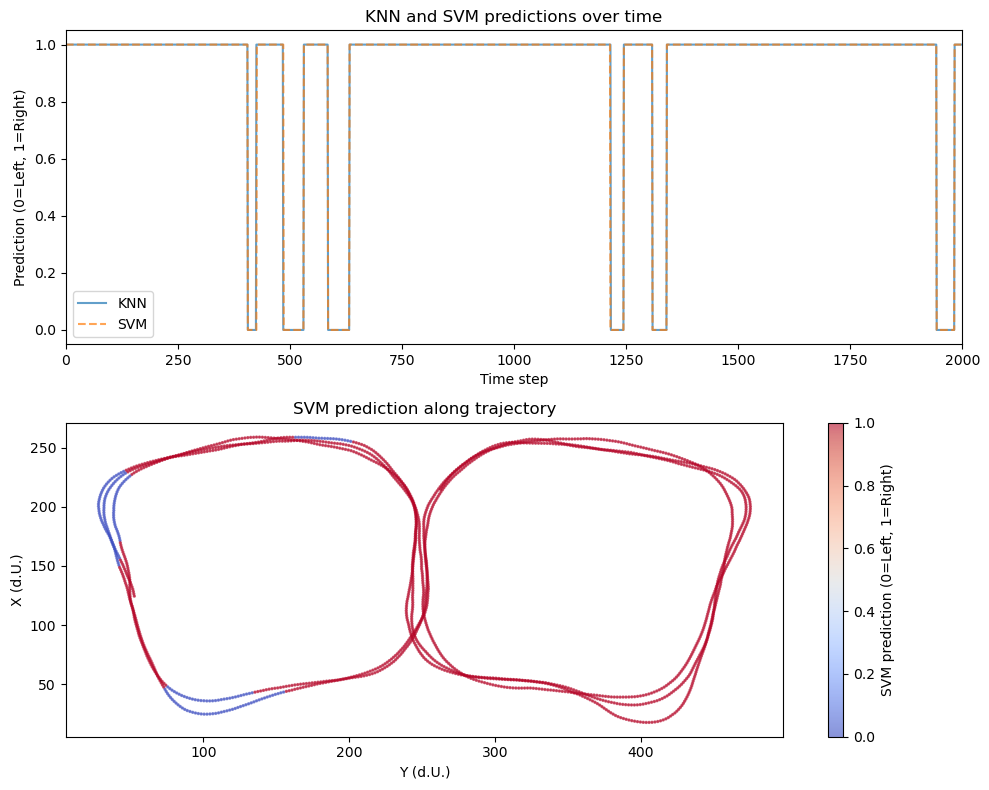

In [14]:

# ── 1. get reservoir states for the full test set (not just yellow zone) ──────
# run reservoir through full test sequence to get states at every timestep
reservoir_states_full = reservoir.run(X[split_index:])  # shape: (N_test, units)

# ── 2. train classifiers on yellow zone states (as before) ────────────────────
# H_yellow, L_yellow already computed from your yellow zone extraction
split = int(0.7 * len(R_yellow))
H_train, H_test = R_yellow[:split], R_yellow[split:]
L_train, L_test = L_yellow[:split], L_yellow[split:]

svm = SVC(kernel='linear')
svm.fit(H_train, L_train)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(H_train, L_train)

# ── 3. run classifiers on full test reservoir states ──────────────────────────
svm_preds_full = svm.predict(reservoir_states_full)   # (N_test,)
knn_preds_full = knn.predict(reservoir_states_full)   # (N_test,)

# ── 4. positions for the full test set ───────────────────────────────────────
x_pos = Data_set[split_index:, 8]   # x coordinates
y_pos = Data_set[split_index:, 9]   # y coordinates

timesteps = 2000  # match the paper's figure

# ── 5. plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# KNN and SVM predictions over time
axes[0].plot(knn_preds_full[:timesteps], label='KNN', alpha=0.7)
axes[0].plot(svm_preds_full[:timesteps], label='SVM', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Prediction (0=Left, 1=Right)')
axes[0].set_title('KNN and SVM predictions over time')
axes[0].set_xlim(0, timesteps)
axes[0].legend()

# SVM prediction overlaid on trajectory
scatter = axes[1].scatter(
    y_pos[:timesteps],          # paper uses Y (d.U.) on x-axis
    x_pos[:timesteps],          # paper uses X (d.U.) on y-axis
    c=svm_preds_full[:timesteps],
    cmap='coolwarm',
    s=2,
    alpha=0.6
)
plt.colorbar(scatter, ax=axes[1], label='SVM prediction (0=Left, 1=Right)')
axes[1].set_xlabel('Y (d.U.)')
axes[1].set_ylabel('X (d.U.)')
axes[1].set_title('SVM prediction along trajectory')

plt.tight_layout()
plt.savefig('esn_50k_prediction_trajectory.png')

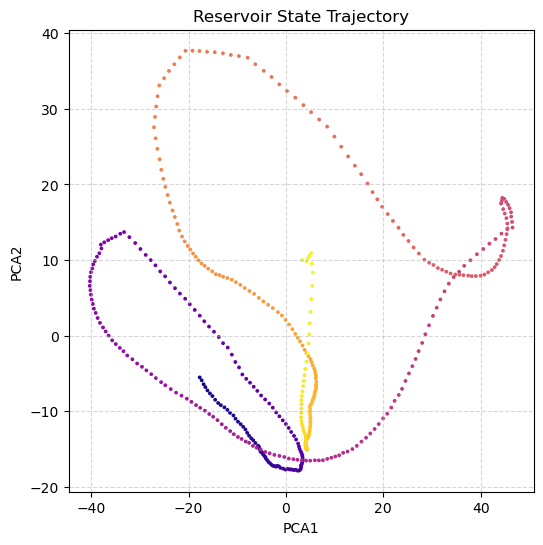

In [18]:
scaler = StandardScaler()
states_scaled = scaler.fit_transform(reservoir_states_all)

pca = PCA(n_components=2)
states_pca = pca.fit_transform(states_scaled)
plt.figure(figsize=(6, 6))
plt.scatter(states_pca[:, 0], states_pca[:, 1], c=range(len(states_pca)), cmap='plasma', s=3)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Reservoir State Trajectory")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('pca_esn_50k_tuned_params.png')

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


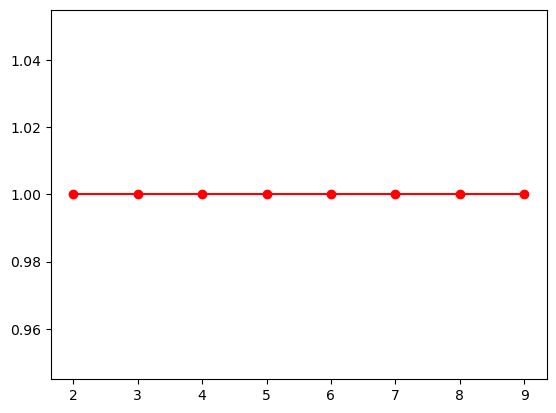

In [5]:
print(knn_scores)
# Elbow method for finding optimal K:
import matplotlib.pyplot as plt
plt.plot(list(range(2,10)), [round(num, 2) for num in knn_scores], 'ro-')
plt.xticks(list(range(2,10)))
plt.savefig('knn_esn_50k_tuned_params.png')

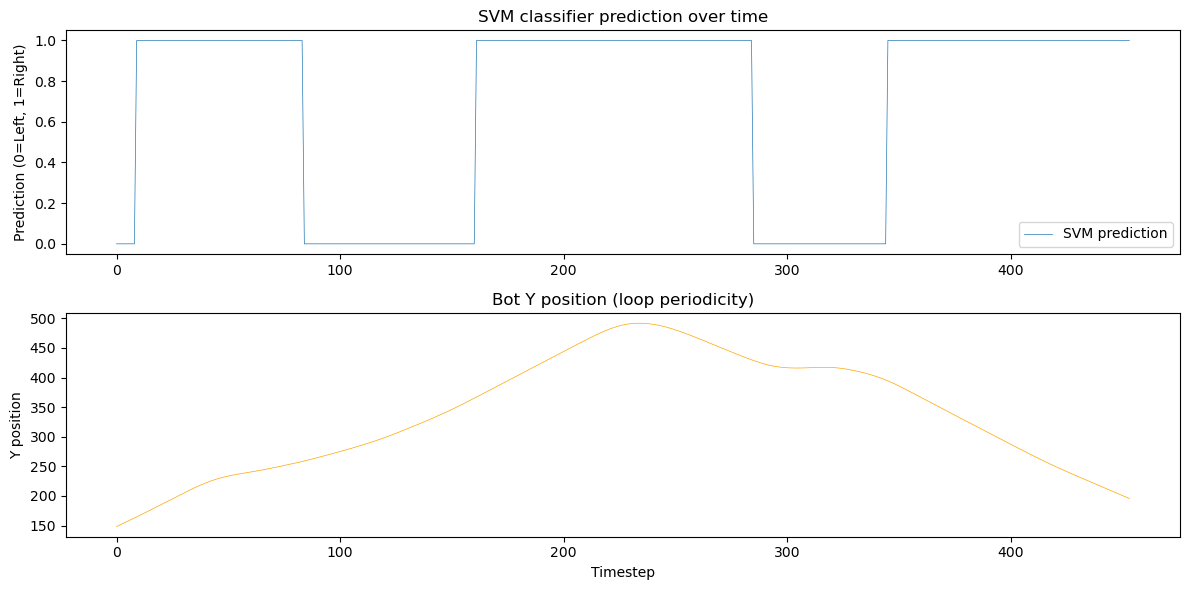

In [6]:
# SVM prediction at every timestep (not just yellow zone) for the plot
svm_full = SVC(kernel='linear')
svm_full.fit(R_train, L_train)
predictions_full = svm_full.predict(reservoir_states_all[:n])

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# top: SVM prediction over time
axes[0].plot(predictions_full, label='SVM prediction', linewidth=0.5)
axes[0].set_ylabel('Prediction (0=Left, 1=Right)')
axes[0].set_title('SVM classifier prediction over time')
axes[0].legend()

# bottom: bot y position over time (shows periodicity of loops)
axes[1].plot(naomi[:n, 11], color='orange', linewidth=0.5)
axes[1].set_ylabel('Y position')
axes[1].set_xlabel('Timestep')
axes[1].set_title('Bot Y position (loop periodicity)')

plt.tight_layout()
plt.show()

In [4]:
print("training_len:", training_len)

print("Data_set[training_len, 8:12]:")
print(Data_set[training_len, 8:12])

print("position:", position)
print("through_walls:", through_walls(position))
print("zone:", get_zones(position))

training_len: 7500
Data_set[training_len, 8:12]:
[ 46.06237582 158.17618246  -5.01777681   0.98370061]
position: [[ -0.55020281 262.36344637]]
through_walls: False
zone: 2




---------- fin de parcours ----------
nombre de pas effectué avant erreur : 237
zone de l'erreur : 4 , au pas 237, nombre de tours: 0,nombre de zones correctement passées: 1




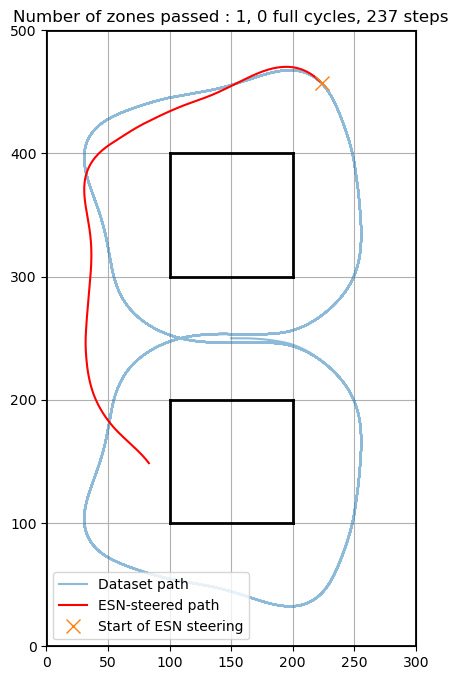

In [2]:
print("\n")
print("-"*10,"fin de parcours","-"*10)
print(f"nombre de pas effectué avant erreur : {n}")
print(f"zone de l'erreur : {zonet1} , au pas {n}, nombre de tours: {idx//6},nombre de zones correctement passées: {idx}")
print("\n")
fig, ax = plt.subplots(figsize=(8, 8))

# Tracé des murs
for wall in walls:
    (x1, y1), (x2, y2) = wall
    ax.plot([x1, x2], [y1, y2], 'k-', linewidth=2)
"""for check in checkpoints:
    (x1, y1), (x2, y2) = check
    ax.plot([x1, x2], [y1, y2], '--', linewidth=2, color='purple', alpha=0.1)"""
# Tracé de la trajectoire du robot
# ax.plot(Data_set[:training_len,8],Data_set[:training_len,9],label='Dataset path', alpha=0.5)
ax.plot(Data_set[:10000,8],Data_set[:10000,9],label='Dataset path', alpha=0.5)

ax.plot(naomi[:n,10], naomi[:n,11], 'r-', label='ESN-steered path')
ax.plot(Data_set[training_len,8],Data_set[training_len,9], 'x', label='Start of ESN steering', markersize=10)
# Options d'affich
ax.set_xlim(0, 300)
ax.set_ylim(0, 500)
ax.set_aspect('equal')
#ax.set_title("Étape 2: trajectoire d'entrainement")
ax.set_title(f"Number of zones passed : {idx}, {idx//6} full cycles, {n} steps")
ax.legend()
plt.grid(True)
plt.show()
#plt.savefig('path_esn_50k_tuned_params.png')

In [1]:
pwd

'/Users/nonon/mamba-root/notebooks/ESN-LSTM/source/Stage-INRIA-2025'